# 2. Filtering

Thinning, cropping, outlier removal and local geometry from `sylva.filters`,
on the Litchfield tile.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import sylva
from sylva import synthetic

DATA = Path("data")          # the Litchfield tile, cut by make_litch_subset.py
plt.rcParams.update({"figure.dpi": 90, "figure.figsize": (7, 4), "axes.grid": False})
from sylva import filters

cloud = sylva.read(DATA / "litch_tile.laz")

## Subsampling

Registered plot clouds are far denser near the scanners than between them.
Voxel downsampling keeps one point per cell, `min_distance_subsample` enforces
a spacing without the grid pattern, and random thinning keeps the density
gradient as it is.

In [2]:
thin = {
    "voxel 10 cm": filters.voxel_downsample(cloud, 0.10),
    "voxel 10 cm (centroid)": filters.voxel_downsample(cloud, 0.10, method="centroid"),
    "random 20 %": filters.random_subsample(cloud, fraction=0.2),
    "min distance 10 cm": filters.min_distance_subsample(cloud, 0.10),
}
for k, v in thin.items():
    print(f"{k:24s} {len(v):>9,} of {len(cloud):,}")

voxel 10 cm                402,192 of 1,553,677
voxel 10 cm (centroid)     402,192 of 1,553,677
random 20 %                310,735 of 1,553,677
min distance 10 cm         171,973 of 1,553,677


## Crops

A box, a circular subplot, and a range shell around a point.

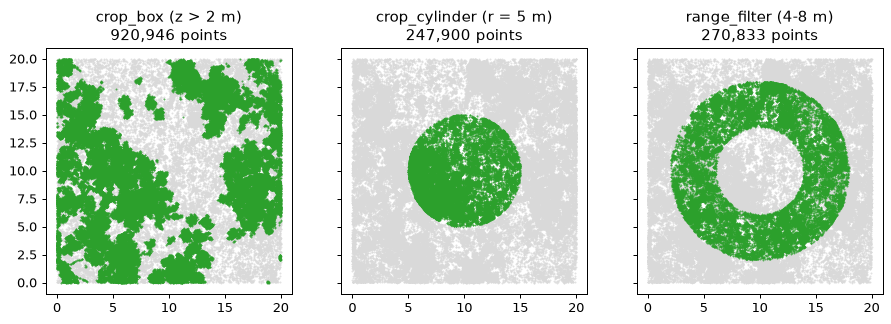

In [3]:
box = filters.crop_box(cloud, (0, 0, 2.0), (20, 20, None))          # everything above 2 m
plot = filters.crop_cylinder(cloud, (10.0, 10.0), radius=5.0)       # a 5 m radius subplot
shell = filters.range_filter(cloud, origin=(10, 10, 1.0), min_range=4.0, max_range=8.0)
fig, ax = plt.subplots(1, 3, figsize=(12, 3.8), sharex=True, sharey=True)
for a, (name, c) in zip(ax, {"crop_box (z > 2 m)": box, "crop_cylinder (r = 5 m)": plot,
                             "range_filter (4-8 m)": shell}.items()):
    a.scatter(cloud.x[::20], cloud.y[::20], s=0.2, c="0.85")
    a.scatter(c.x[::8], c.y[::8], s=0.2, c="C2")
    a.set(title=f"{name}\n{len(c):,} points", aspect="equal")

## Outliers

Two filters, both deciding from the neighbourhood: statistical removal compares
each point's mean distance to its `k` neighbours against the cloud-wide
distribution, radius removal needs a minimum count inside a ball. On real data there is no
truth to check against, so look at what they actually take. Here the two
disagree completely: the statistical filter removes 4 % of the cloud, most of
it the thin grass layer near the ground, because sparse-but-real vegetation
looks like noise by that test; the radius filter removes 77 genuinely isolated
points. Tune on the part of the cloud you care about, or the filter will eat
the understorey.

In [4]:
thinned = filters.voxel_downsample(cloud, 0.05)
sor = filters.statistical_outlier_removal(thinned, k=8, std_ratio=2.0, return_mask=True)
ror = filters.radius_outlier_removal(thinned, radius=0.25, min_neighbors=4, return_mask=True)
for name, keep in (("statistical (k=8, 2 sd)", sor), ("radius (0.25 m, 4)", ror)):
    drop = ~keep
    print(f"{name:24s} drops {drop.sum():>6,} ({drop.mean():.2%}); "
          f"median height of dropped points {np.median(thinned.z[drop]):5.1f} m vs {np.median(thinned.z):.1f} m overall")

statistical (k=8, 2 sd)  drops 58,409 (3.87%); median height of dropped points   0.5 m vs 7.5 m overall
radius (0.25 m, 4)       drops     77 (0.01%); median height of dropped points   6.6 m vs 7.5 m overall


dropped by the statistical filter below 1 m: 63%


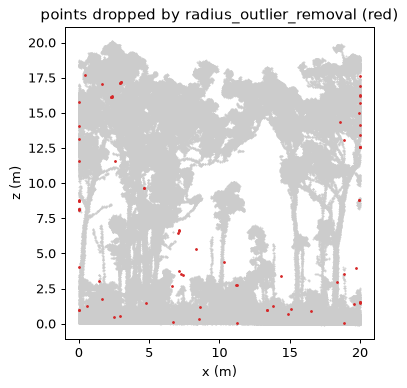

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
drop = ~ror
ax.scatter(thinned.x[::4], thinned.z[::4], s=0.2, c="0.8")
ax.scatter(thinned.x[drop], thinned.z[drop], s=1.5, c="C3")
ax.set(title="points dropped by radius_outlier_removal (red)", xlabel="x (m)", ylabel="z (m)", aspect="equal");
print("dropped by the statistical filter below 1 m:", f"{np.mean(thinned.z[~sor] < 1.0):.0%}")

## Local geometry

PCA over the `k` nearest neighbours gives normals and the planarity / linearity
the wood filter uses. On a real stem, bark is locally planar and the trunk
is linear at metre scale, while the grass layer is neither.

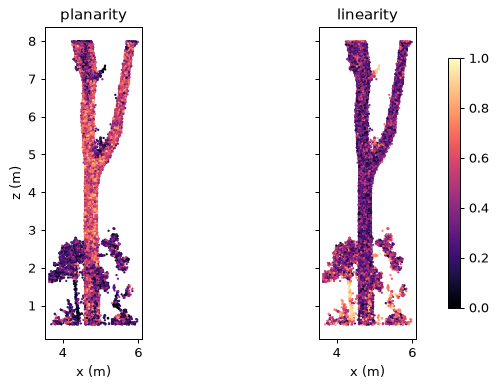

In [6]:
stem = filters.crop_cylinder(cloud, (4.8, 7.5), radius=1.2, zmin=0.5, zmax=8.0)
planarity, linearity = filters.planarity_linearity(stem, k=20)
fig, ax = plt.subplots(1, 2, figsize=(9, 4.5), sharey=True)
for a, v, name in ((ax[0], planarity, "planarity"), (ax[1], linearity, "linearity")):
    sc = a.scatter(stem.x, stem.z, c=v, s=0.6, cmap="magma", vmin=0, vmax=1)
    a.set(title=name, xlabel="x (m)", aspect="equal")
ax[0].set_ylabel("z (m)")
fig.colorbar(sc, ax=ax, shrink=0.8);

## Clustering

`euclidean_clusters` labels connected components of the radius graph. Above the
grass layer the savanna crowns mostly separate, which is the cheap version of
tree segmentation -- notebook 5 does it properly, because crowns that touch
merge here.

clusters: 30  unassigned points: 1294  largest cluster: 36065 points


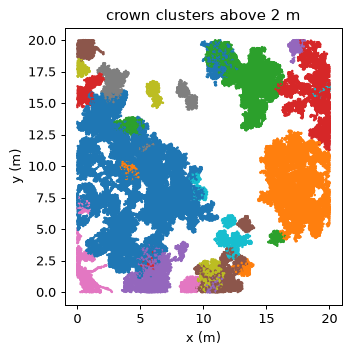

In [7]:
above = filters.voxel_downsample(cloud[cloud.z > 2.0], 0.15)
labels = filters.euclidean_clusters(above.xyz, radius=0.4, min_points=200)
print("clusters:", labels.max() + 1, " unassigned points:", int(np.sum(labels < 0)),
      " largest cluster:", int(np.sum(labels == 0)), "points")
plt.scatter(above.x, above.y, c=np.where(labels < 0, np.nan, labels % 10), s=1.0, cmap="tab10")
plt.gca().set(aspect="equal", xlabel="x (m)", ylabel="y (m)", title="crown clusters above 2 m");